# Funciones de distribucion de probabilidad

### Distribucion uniforme

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Text(0.5, 1.0, 'Uniform distribution')

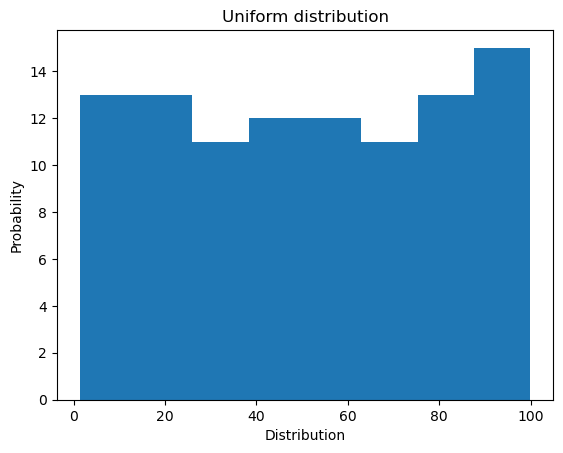

In [2]:
np.random.seed(2018)
a = 1
b = 100
n = 100
data = np.random.uniform(a,b,n)
plt.hist(data, bins = int(np.ceil(1 + np.log2(len(data)))))
plt.xlabel("Distribution")
plt.ylabel("Probability")
plt.title("Uniform distribution")

### Distribucion normal

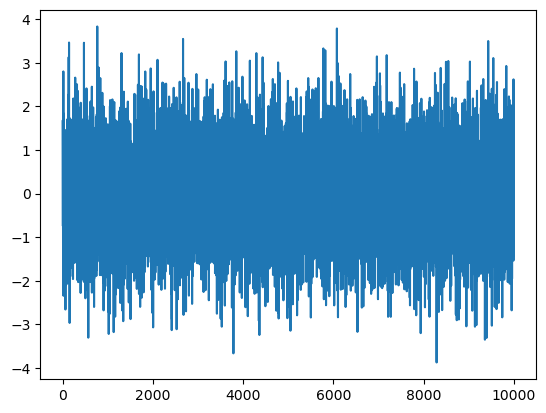

In [31]:
data = np.random.randn(10000)
x = range(0,10000)
plt.plot(x,data)

(array([ 1.,  5., 13., 22., 23., 20., 10.,  6.]),
 array([-2.64456044, -1.99281594, -1.34107144, -0.68932694, -0.03758244,
         0.61416205,  1.26590655,  1.91765105,  2.56939555]),
 <BarContainer object of 8 artists>)

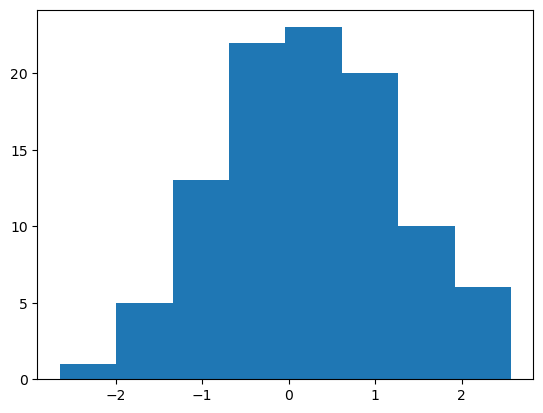

In [10]:
plt.hist(data, bins = int(np.ceil(1 + np.log2(len(data)))))


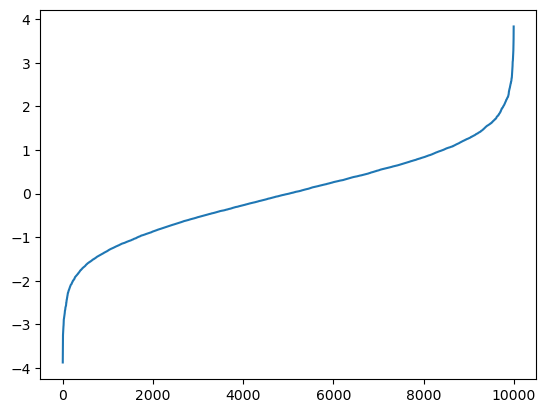

In [32]:
plt.plot(x,sorted(data))

(array([  8.,  22.,  98., 238., 274., 241.,  97.,  21.,   0.,   1.]),
 array([-3.05065858, -1.15603951,  0.73857956,  2.63319863,  4.5278177 ,
         6.42243677,  8.31705584, 10.21167491, 12.10629398, 14.00091304,
        15.89553211]),
 <BarContainer object of 10 artists>)

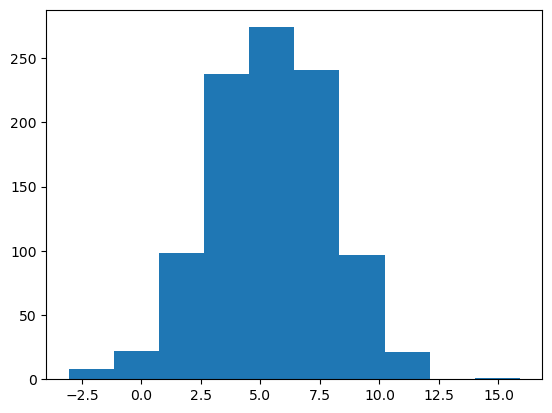

In [35]:
mu = 5.5
sd = 2.5
data = mu + sd*np.random.randn(1000) # Z = (X - mu) / sd --> N(0,1), x = mu + sd * Z
plt.hist(data)

(array([  5.,  14.,  59., 141., 249., 240., 189.,  80.,  15.,   8.]),
 array([-3.33857648, -2.68089091, -2.02320534, -1.36551978, -0.70783421,
        -0.05014865,  0.60753692,  1.26522249,  1.92290805,  2.58059362,
         3.23827919]),
 <BarContainer object of 10 artists>)

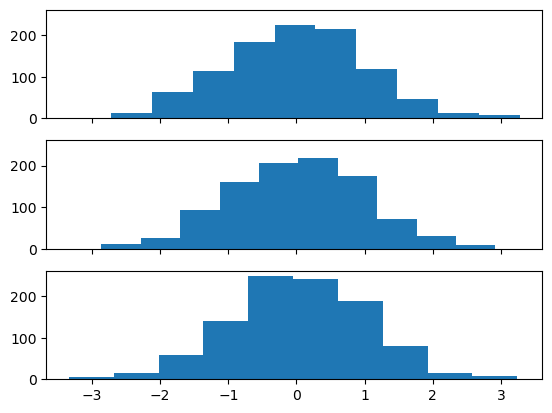

In [47]:
figure, axs = plt.subplots(3,1,sharey = True,sharex = True)
data = np.random.randn(3,1000)
axs[0].hist(data[0])
axs[1].hist(data[1])
axs[2].hist(data[2])

## La simulacion de Monte Carlo

* Generamos 2 numeros aleatorios entre 0 y 1 en total 1000 veces
* Calcularemos x * x + y * y
    * Si el valor es inferior 1 -> estamos dentro dle circulo
    * Si el valor es superior a 1 -> estamos fuera del circulo
* Calculamos el numero total de veces que estan dentro del circulo y lo devidimos entre el numero total de intentos para tener una aproximacion de la    probabilidad de caer dentro del Circulo
* Usamos dicha probabilidad para aproximar el valor de pi
* Repetimos el experimento un numero suficiente de veces (Por ejemplo 100), para obtener diferentes aproximaciones de pi
* Calculamos el promedio de los 100 experimentos anteriores para dar un valor final de pi.
    

In [61]:
def pi_montecarlo(n,n_exp):
    pi_avg = 0
    pi_value_list = []
    for i in range(n_exp):
        value = 0
        x = np.random.uniform(0,1,n).tolist()
        y = np.random.uniform(0,1,n).tolist()
        for j in range(n):
            z = np.sqrt(x[j] * x[j] + y[j]*y[j])
            if z <= 1:
                value += 1
        float_value = float(value)
        pi_value = float_value*4 / n
        pi_value_list.append(pi_value)
        pi_avg += pi_value
    pi = pi_avg/n_exp
    print(pi)
    fig = plt.plot(pi_value_list)
    return (pi,fig)

3.1431019999999994


(3.1431019999999994, [<matplotlib.lines.Line2D at 0x21e8f513c50>])

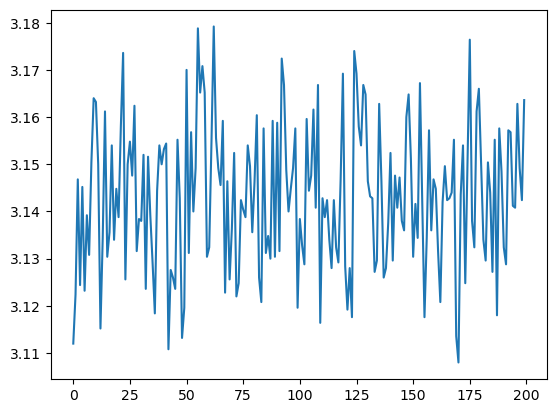

In [63]:
pi_montecarlo(10000,200)

### Una opcion vectorizada usando ChatGPT

In [57]:
x = np.random.uniform(0,1,n)
y = np.random.uniform(0,1,n)

inside = np.sum(x**2 + y**2 <= 1)

pi = 4*inside/n
print(pi)

3.224


### Generacion de Dummy Datasets

In [72]:
n = 100000
data = pd.DataFrame(
    {
        'A':np.random.randn(n),
        'B': 1.5 + 2.5*np.random.randn(n),
        'C': np.random.uniform(5,32,n)
    }    
)
data.describe()

,A,B,C
count,100000.000000,100000.000000,100000.000000
mean,-0.000611,1.507046,18.507582
std,1.000943,2.495256,7.805683
min,-4.065481,-11.277315,5.000141
25%,-0.674576,-0.183312,11.764705
50%,-0.001569,1.505880,18.500698
75%,0.674884,3.185434,25.286759
max,4.005795,12.947418,31.999722


(array([   57.,   687.,  4259., 15165., 28720., 29257., 16221.,  4801.,
          767.,    66.]),
 array([-4.06548114, -3.2583535 , -2.45122586, -1.64409821, -0.83697057,
        -0.02984293,  0.77728471,  1.58441235,  2.39153999,  3.19866763,
         4.00579527]),
 <BarContainer object of 10 artists>)

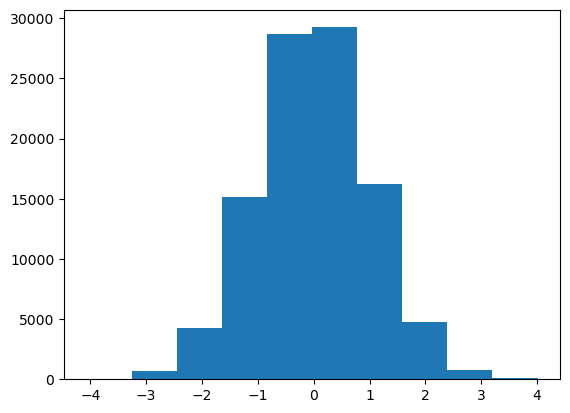

In [73]:
plt.hist(data["A"])

(array([3.0000e+00, 8.8000e+01, 1.2030e+03, 9.3900e+03, 2.8785e+04,
        3.6428e+04, 1.9326e+04, 4.3470e+03, 4.0900e+02, 2.1000e+01]),
 array([-11.27731482,  -8.85484153,  -6.43236824,  -4.00989495,
         -1.58742166,   0.83505162,   3.25752491,   5.6799982 ,
          8.10247149,  10.52494478,  12.94741807]),
 <BarContainer object of 10 artists>)

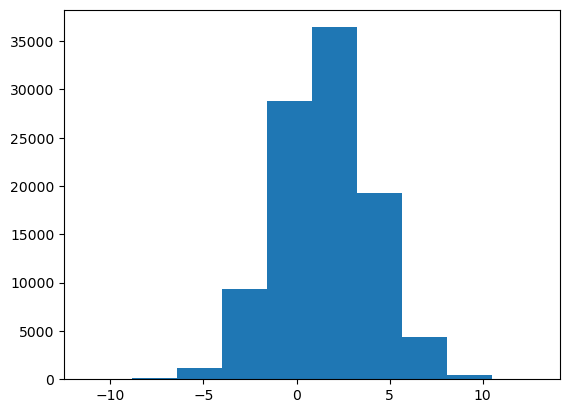

In [74]:
plt.hist(data["B"])

(array([10064.,  9914., 10061.,  9932., 10023.,  9928.,  9986.,  9919.,
        10138., 10035.]),
 array([ 5.0001406 ,  7.70009876, 10.40005691, 13.10001507, 15.79997323,
        18.49993138, 21.19988954, 23.89984769, 26.59980585, 29.299764  ,
        31.99972216]),
 <BarContainer object of 10 artists>)

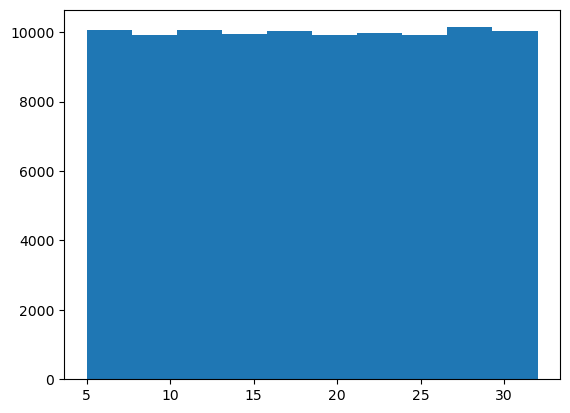

In [75]:
plt.hist(data["C"])

In [78]:
data = pd.read_csv("..\datasets\customer-churn-model\Customer Churn Model.txt")
data.head()

,State,Account Length,Area Code,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False.
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.


In [79]:
data.describe()

,Account Length,Area Code,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [80]:
column_names = data.columns.values.tolist()

In [81]:
a = len(column_names)
a

21

In [82]:
new_data = pd.DataFrame(
    {
        'Column name': column_names,
        'A': np.random.randn(a),
        'B': np.random.uniform(0,1,a)  
    }
)
new_data.head()

,Column name,A,B
0,State,-1.139234,0.846225
1,Account Length,-0.169407,0.610295
2,Area Code,0.192996,0.198027
3,Phone,1.710333,0.480294
4,Int'l Plan,-1.199414,0.813695


In [83]:
new_data = pd.DataFrame(
    {
        'Column name': column_names,
        'A': np.random.randn(a),
        'B': np.random.uniform(0,1,a)  
    }, index = range(42,42 + a)
)
new_data.head()

,Column name,A,B
42,State,-1.358837,0.075658
43,Account Length,-2.594935,0.465939
44,Area Code,0.554848,0.934826
45,Phone,0.139018,0.787107
46,Int'l Plan,-0.678852,0.652948


Esta modificacion de indices es especialmente util cuando quiero unir diferentes datasets, pero hay uno que empieza a partir de un punto determinado.